### **Part III: Linear & Ridge Regressions using OLS**
#### **Step 1: Preprocessing on Different dataset**

In [2]:
# This is a blueprint for preprocessing datasets, so we would know what all funtions are there in this class.
class PreprocessPipeline:
  def getfileForProcessing():
    return None
  def importLibraries(self):
    return None
  def handleMissingValues(self,copydf):
    return None
  def handleStringValues(self,df):
    return None
  def handleOutliers(self,df):
    return None
  def funcHotEncoding(self, df,targetColumn):
    return None
  def scalingValues(self,df):
    return None
  def to_numeric(self,df):
    return None
  def fit_transform(self,df):
    return None

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class PreprocessPipeline:
    def __init__(self, path="penguins.csv", one_hot_cols=None, label_encode_cols=None):
        # Initialize the values that would be needed in other funtions so we dont have to send the value again and again while calling the function
        self.path = path
        self.df = None
        self.scaled_df = None
        self.settings = {}
        self.one_hot_cols = one_hot_cols
        self.label_encode_cols = label_encode_cols

    def load_data(self):
      # Imported the dataset from csv
        self.df = pd.read_csv(self.path)
        #print(self.df.head(2))
        #print(self.df.shape)
        #print(self.df.dtypes)
        self.settings["loaded"] = f"Data loaded from {self.path} with shape {self.df.shape}"
        self.df.drop(columns=['Unnamed: 0'], inplace=True) #Dropping the unnamed column, as it didnt provide any significance to the output

        return self.df

    def handle_missing(self):
      # Found the threshold and if the nan value is below it then drop that
        print('Before Null values : \n',self.df.isnull().sum())
        self.df = self.df.dropna(thresh=len(self.df.columns)//2)
        for col in self.df.select_dtypes(include=["object"]).columns:
            self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
            #print('Missing values: \n',self.df)
        for col in self.df.select_dtypes(include=["int64","float64"]).columns:
            self.df[col] = self.df[col].fillna(self.df[col].median())
        print('After dropping Null values : \n',self.df.isnull().sum())
        self.settings["missing"] = "Dropped rows with >50% missing, filled categorical with mode, numeric with median"

    def clean_strings(self):
      # Made all the string in the dataset to lowercase
        for col in self.df.select_dtypes(include=["object"]).columns:
            self.df[col] = self.df[col].astype(str).str.strip().str.lower()
        self.settings["string_clean"] = "Stripped and lowercased strings"

    def handle_outliers(self):
      # Used IQR method to handel outliers
        for col in self.df.select_dtypes(include=["int64","float64"]).columns:
            Q1 = self.df[col].quantile(0.25)
            Q3 = self.df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower, upper = Q1 - 1*IQR, Q3 + 1*IQR
            self.df[col] = np.where(self.df[col] < lower, self.df[col].mean(), self.df[col])
            self.df[col] = np.where(self.df[col] > upper, self.df[col].mean(), self.df[col])
        self.settings["outliers"] = "Outliers capped with mean using 1*IQR"

    def encode_categoricals(self):
      # Encoded by Onehot method for any column and if not given then by default for penguin dataset did for gender.
      #  if "gender" in self.df.columns:
      #     self.df["gender_encode"] = self.df["gender"].map({"male": 0, "female": 1})
        for col in self.one_hot_cols:
            if col in self.df.columns:
                encoded = pd.get_dummies(self.df[col], prefix=col, drop_first=True, dtype=int)
                self.df.drop(columns=[col], inplace=True)
                self.df = pd.concat([self.df, encoded], axis=1)
        #Added new condition to check if no label encoding is needed, we skip it or else we perform label encoding
        if self.label_encode_cols is None:
          pass
        else:
          for col in self.label_encode_cols:
              if col in self.df.columns:
                  self.df[col + "_encoded"] = self.df[col].astype("category").cat.codes
                  self.df.drop(columns=[col], inplace=True)
          self.settings["encoding"] = f"Label encoded: {self.label_encode_cols}, One-hot encoded: {self.one_hot_cols}"

    def to_numeric(self):
      # Made all the columns to numeric which are of object datatype
        for col in self.df.columns:
          if col in self.df.select_dtypes(include=["object"]).columns:
            self.df[col] = pd.to_numeric(self.df[col], errors='coerce')

        #print('Calling from function numeric: ',self.handle_missing())

    def scale_numeric(self):
        # Only scale numeric columns if they exist in the dataset
        num_cols = ["average us salary","number of diamonds mined (millions)","price","depth","table"]
        self.scaled_df = self.df.copy()
        existing_cols = [col for col in num_cols if col in self.scaled_df.columns]
        for col in existing_cols:
            min_val = self.scaled_df[col].min()
            max_val = self.scaled_df[col].max()
            self.scaled_df[col] = (self.scaled_df[col] - min_val) / (max_val - min_val)
        self.settings["scaling"] = {col:(self.scaled_df[col].min(), self.scaled_df[col].max()) for col in existing_cols}

    def fit_transform(self):
      # Called all the function in one place
        self.load_data()
        self.handle_missing()
        self.clean_strings()
        self.handle_outliers()
        self.encode_categoricals()
        self.to_numeric()
        self.handle_missing()
        self.handle_outliers()
        self.scale_numeric()
        return self.scaled_df


In [4]:
Mypipeline = PreprocessPipeline(path="diamond.csv", one_hot_cols=["color","clarity","cut"])
cleaned_df = Mypipeline.fit_transform()
print("\nCleaned dataset preview (first 5 rows):\n", cleaned_df.head(5))
print("\n Cleaned dataset datatype: \n", cleaned_df.dtypes)
print("Cleaned dataset shape:\n", cleaned_df.shape)
#Mypipeline.visualizeData()
cleaned_df.to_csv("diamond_preprocessed.csv", index=False)
corr_matrix = cleaned_df.corr()
#print(corr_matrix)


Before Null values : 
 carat                                  1510
cut                                    1293
color                                  1512
clarity                                 353
average us salary                         0
number of diamonds mined (millions)       0
depth                                   694
table                                  1542
price                                  1583
x                                      1526
y                                      1221
z                                      1433
dtype: int64
After dropping Null values : 
 carat                                  0
cut                                    0
color                                  0
clarity                                0
average us salary                      0
number of diamonds mined (millions)    0
depth                                  0
table                                  0
price                                  0
x                                   

carat                                  0.813019
average us salary                      0.001086
number of diamonds mined (millions)   -0.003777
depth                                  0.029010
table                                  0.143605
x                                      0.797715
y                                      0.784274
z                                      0.777224
color_e                               -0.095166
color_f                               -0.015672
color_false                           -0.008352
color_g                                0.014355
color_h                                0.063232
color_i                                0.060898
color_j                                0.081466
color_maybe                           -0.008203
color_true                            -0.008906
clarity_i1                             0.029904
clarity_if                            -0.085090
clarity_maybe                         -0.009114
clarity_si1                            0

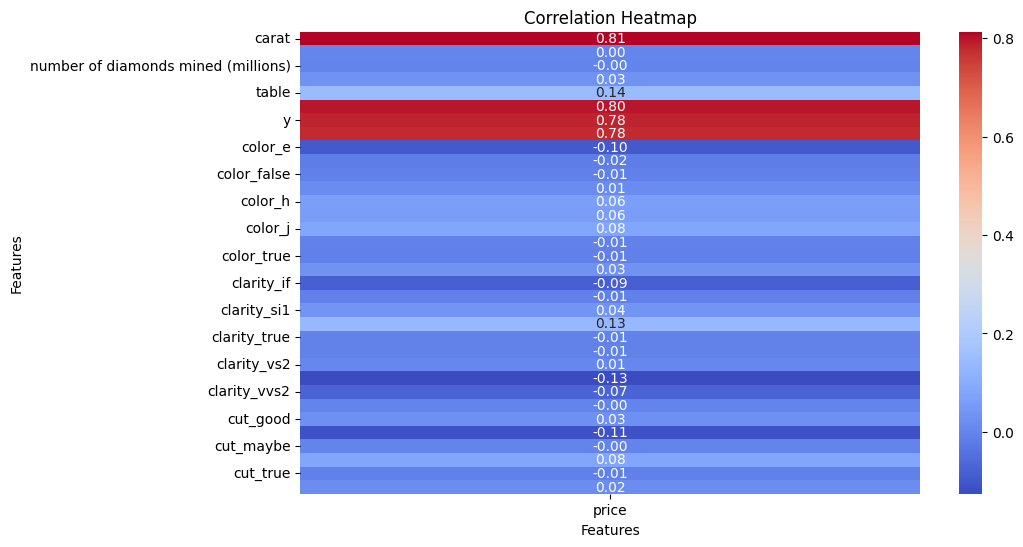

Set of features needed:  Index(['carat', 'x', 'y', 'z'], dtype='object')


In [5]:
#Keeping the predicted column to be price in our scenario

import matplotlib.pyplot as plt
import seaborn as sns

target_corr = corr_matrix['price'].drop('price')
print(target_corr)

plt.figure(figsize=(10,6))
sns.heatmap(target_corr.to_frame(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()


columnsNeeded = target_corr[(target_corr) >= 0.3].index
print('Set of features needed: ',columnsNeeded)
cleaned_df = cleaned_df[columnsNeeded.tolist() + ['price']]


In [6]:

np.random.seed(42)

#print('Values null there or not in the cleaned_df',cleaned_df.isnull().sum())
#Storing values with X column without the target variable
Y = cleaned_df["price"]
X = cleaned_df.drop(columns=["price"])

#print(Y.isnull().sum())
#print(X.isnull().sum())

rows = X.shape[0]
#print(rows)

print('Initial value of non target variable: \n',X.shape)
print('Initial value of target variable: \n',Y.shape)

indices = np.arange(rows)
np.random.shuffle(indices)
#print(indices)

split_size = int(0.8 * rows)

train_idx = indices[:split_size]
test_idx = indices[split_size:]

'''print(train_idx.shape)
print(test_idx.shape)'''

#Defining the model
X_train = X.iloc[train_idx]
y_train = Y.iloc[train_idx]
X_test = X.iloc[test_idx]
y_test = Y.iloc[test_idx]

print('Value of X train: ',X_train.shape)
print('Value of Y train: ',y_train.shape)
print('Value of X test shape: ',X_test.shape)
print('Value of Y test shape: ',y_test.shape)


Initial value of non target variable: 
 (53925, 4)
Initial value of target variable: 
 (53925,)
Value of X train:  (43140, 4)
Value of Y train:  (43140,)
Value of X test shape:  (10785, 4)
Value of Y test shape:  (10785,)


In [7]:
#To calculate the weights using OLS

#Before
print('Before X Type: \n',type(X_train))
print('Before Y Type: \n',type(y_train))
print('Before X shape: \n',X_train.shape)
print('Before Y shape: \n',y_train.shape)

#After
#Converting to numpy to perform operations
y_np = y_train.to_numpy().reshape(-1, 1)
X_np = X_train.to_numpy()
y_np_test = y_test.to_numpy().reshape(-1,1)
X_np_test = X_test.to_numpy()
print('After X Type: \n',type(X_np))
print('After X shape: \n',X_np.shape)
print('After Y Type: \n',type(y_np))
print('After Y shape: \n',y_np.shape)

#print('Null weights: ',X_train.isnull().sum())

#Transpose matrix
#print('Before Transpose matrix : \n',X_np)
#print('Transpose matrix : \n',X_np.T)


#Using linalg.inv to calculate the unverse of the matrix
weights = np.linalg.inv(X_np.T @ X_np) @ X_np.T @ y_np
print('Weights of the OLS method : \n',weights.shape)

#Making predictions
y_pred_train = X_np @ weights
print('Model prediction for training  data: \n',y_pred_train.shape)
y_pred_test = X_np_test @ weights
print('Model prediction for testing data : \n',y_pred_test.shape)

Before X Type: 
 <class 'pandas.core.frame.DataFrame'>
Before Y Type: 
 <class 'pandas.core.series.Series'>
Before X shape: 
 (43140, 4)
Before Y shape: 
 (43140,)
After X Type: 
 <class 'numpy.ndarray'>
After X shape: 
 (43140, 4)
After Y Type: 
 <class 'numpy.ndarray'>
After Y shape: 
 (43140, 1)
Weights of the OLS method : 
 (4, 1)
Model prediction for training  data: 
 (43140, 1)
Model prediction for testing data : 
 (10785, 1)


In [8]:
#Computing Mean squared error & coefficient of determination (R2)
mse_testval = np.mean((y_np_test-y_pred_test)**2)
print('Mean square error of Test data: \n',mse_testval)

mse_trainval = np.mean((y_np-y_pred_train)**2)
print('Mean square error of Train data: \n',mse_trainval)

#Calculating now the R2
#Training data set
residual_train = y_np - y_pred_train
squaredvaltrain = residual_train ** 2

squaredvaltrain = np.sum(squaredvaltrain)
#print('Sum of squared residuals train: \n',squaredvaltrain)

totalsumtrain = np.sum((y_np - np.mean(y_np))**2)
#print('Total sum of train: \n',totalsumtrain)

#Testing data set
residual_test = y_np_test - y_pred_test
squaredvaltest = residual_test ** 2

squaredvaltest = np.sum(squaredvaltest)
#print('Sum of squared residuals for test: \n',squaredvaltest)

totalsumtest = np.sum((y_np_test - np.mean(y_np_test))**2)
#print('Total sum of train: \n',totalsumtest)


#Calcualting R2
R2train = (1- squaredvaltrain/totalsumtrain)
print('R2 value for train data: \n',R2train)

R2test = (1- squaredvaltest/totalsumtest)
print('R2 value for test data: \n',R2test)


Mean square error of Test data: 
 0.020211628229424433
Mean square error of Train data: 
 0.019918808728377556
R2 value for train data: 
 0.6421248869549172
R2 value for test data: 
 0.6431440152685899


 #### Ridge Regression using OLS:

Values for the lambda passed 0.01
Model prediction for training  data: (43140, 1)
Model prediction for testing data : (10785, 1)
Training loss:  0.011365273643306813
TestLoss:  0.011511683380688854
Mean square error of Train data:  0.019918808728614693
Mean square error of Test data:  0.020211628203378778
R2 value for train data:  0.6421248869506566
R2 value for test data:  0.6431440157284514


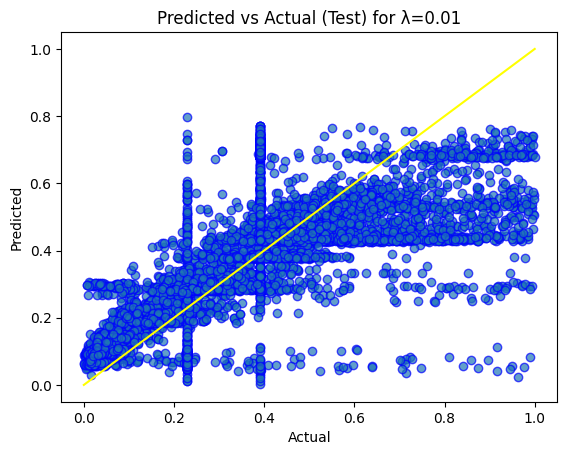

-------------------------------------------------------------
Values for the lambda passed 0.1
Model prediction for training  data: (43140, 1)
Model prediction for testing data : (10785, 1)
Training loss:  0.024017176505228825
TestLoss:  0.024163586124635858
Mean square error of Train data:  0.01991880875208973
Mean square error of Test data:  0.0202116279909038
R2 value for train data:  0.6421248865288879
R2 value for test data:  0.6431440194799041


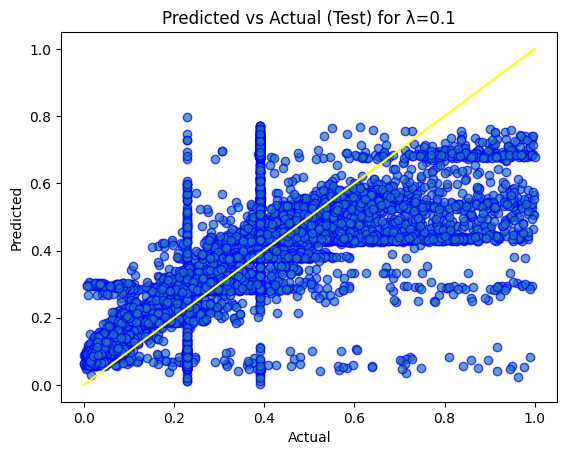

-------------------------------------------------------------
Values for the lambda passed 1
Model prediction for training  data: (43140, 1)
Model prediction for testing data : (10785, 1)
Training loss:  0.1504451113158357
TestLoss:  0.15059151978492463
Mean square error of Train data:  0.019918811098016787
Mean square error of Test data:  0.020211628036194647
R2 value for train data:  0.6421248443803377
R2 value for test data:  0.64314401868025


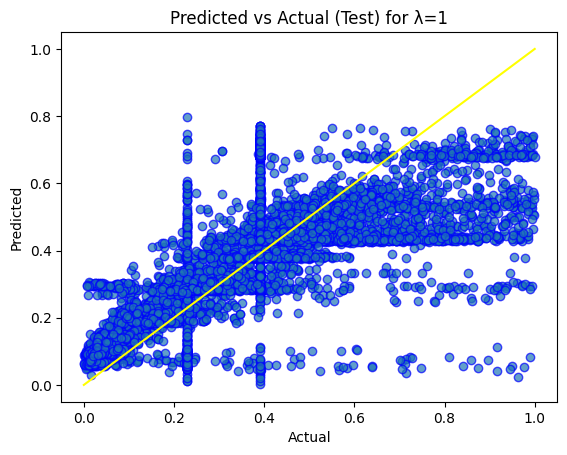

-------------------------------------------------------------
Values for the lambda passed 10
Model prediction for training  data: (43140, 1)
Model prediction for testing data : (10785, 1)
Training loss:  1.4056653309641662
TestLoss:  1.4058117308479514
Mean square error of Train data:  0.01991904412285526
Mean square error of Test data:  0.020211843890425546
R2 value for train data:  0.6421206576947005
R2 value for test data:  0.6431402075635378


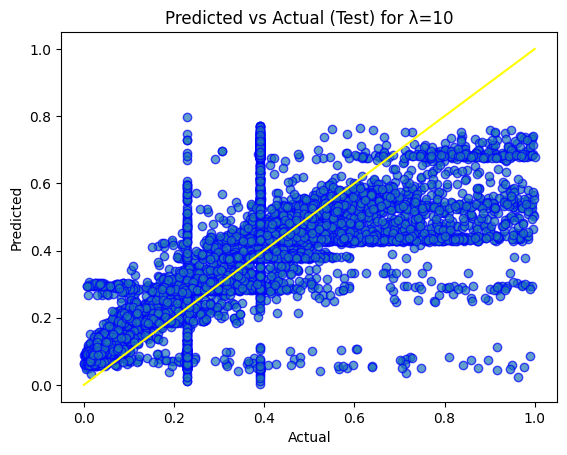

-------------------------------------------------------------


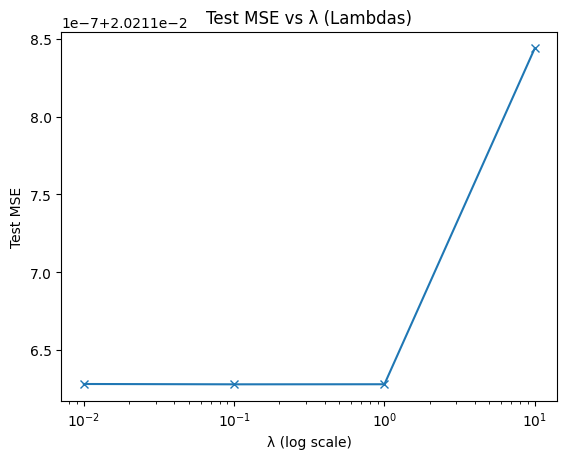

Index val:  1
Optimal weights 
 [[ 0.52917148]
 [-0.0061832 ]
 [ 0.01004632]
 [-0.03152496]]
Best λ: 0.1
Test MSE (optimal): 0.0202116279909038
Test R² (optimal ): 0.6431440194799041
Weights shape: (4, 1)


In [9]:
#Calculating ridge regression using OLS

def mean_squared_error(Y,Y_pred):
  return np.mean((Y-Y_pred)**2)

def residual_sum_of_squares(Y,Y_pred):
  residual_train = Y - Y_pred
  squaredvaltrain = residual_train ** 2

  squaredvaltrain = np.sum(squaredvaltrain)
  #print('Sum of squared residuals train: \n',squaredvaltrain)

  totalsumtrain = np.sum((Y - np.mean(Y))**2)
  #print('Total sum of train: \n',totalsumtrain)

  R2train = (1- squaredvaltrain/totalsumtrain)
  return R2train
#Creating the ridge loss function to compute the los
def ridgeLoss(X,y,w,lam):
  N = X.shape[0]
  #print(N)
  y_pred = X @ w
  difference = y-y_pred
  l2_loss = (1 / (2 * N)) * np.sum(difference ** 2)
  reg_term = 0.5 * lam * (w.T @ w)
  total_loss = l2_loss + reg_term
  return total_loss.item()

#Changing/calculating weights
def calculate_ridge_weights(X, y, lam):
  I = np.eye(X.shape[1])
  w = np.linalg.inv(X.T @ X + lam * I) @ X.T @ y
  return w

lambdasval = [0.01, 0.1, 1, 10]
weightlist = []
trainList = []
testList = []
trainMSEList = []
testMSEList = []
R2trainList = []
R2testList = []


for lam in lambdasval:
  weight = calculate_ridge_weights(X_np,y_np,lam)
  weightlist.append(weight)

  trainLoss = ridgeLoss(X_np,y_np,weight,lam)
  testLoss = ridgeLoss(X_np_test,y_np_test,weight,lam)
  trainList.append(trainLoss)
  testList.append(testLoss)

  #Model predictions
  y_pred_train = X_np @ weight
  y_pred_test = X_np_test @ weight


  print(f'Values for the lambda passed {lam}')
  print(f'Model prediction for training  data: {y_pred_train.shape}')
  print('Model prediction for testing data :' ,y_pred_test.shape)
  print('Training loss: ',trainLoss)
  print('TestLoss: ',testLoss)


  #Now to calculate the MSE and R2
  mse_trainval = mean_squared_error(y_np,y_pred_train)
  print('Mean square error of Train data: ',mse_trainval)
  trainMSEList.append(mse_trainval)
  mse_testval = mean_squared_error(y_np_test,y_pred_test)
  print('Mean square error of Test data: ',mse_testval)
  testMSEList.append(mse_testval)

  #Calculating now the R2
  #Training data set
  r2Trainval = residual_sum_of_squares(y_np,y_pred_train)
  print('R2 value for train data: ',r2Trainval)
  R2trainList.append(r2Trainval)

  #Testing data set
  r2Testval = residual_sum_of_squares(y_np_test,y_pred_test)
  print('R2 value for test data: ',r2Testval)
  R2testList.append(r2Testval)

  plt.figure()
  plt.scatter(y_test, y_pred_test, alpha=0.7, edgecolors='blue')
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='yellow')
  plt.title(f'Predicted vs Actual (Test) for λ={lam}')
  plt.xlabel('Actual')
  plt.ylabel('Predicted')
  plt.show()
  print('-------------------------------------------------------------')

plt.figure()
plt.plot(lambdasval, testMSEList, marker='x')
plt.xscale('log')
plt.title('Test MSE vs λ (Lambdas)')
plt.xlabel('λ (log scale)')
plt.ylabel('Test MSE')
plt.show()

#Calculating the Best Mse and R2 wrt the weights used
indexVal = np.argmin(testMSEList)
print('Index val: ',indexVal)
lambdaBest = lambdasval[indexVal]
#print('Lambda val: ',lambdaBest)
optimalweight = weightlist[indexVal]
print('Optimal weights \n',optimalweight)

print(f'Best λ: {lambdaBest}')
print(f'Test MSE (optimal): {testMSEList[indexVal]}')
print(f'Test R² (optimal ): {R2testList[indexVal]}')
print(f'Weights shape: {optimalweight.shape}')




In [11]:
import pickle

with open("a1_part_3_weights_rajagop6_raviraja.pkl", "wb") as f:
    pickle.dump(optimalweight, f)

Discussion (write in the markdown cell):
- What are the benefits and drawbacks of using closed-form OLS?
- Ans -> Easy to build, unlike gradient descent we saved time because there is no loop to run and can provide efficeient results , Drawbacks are might be slower when features are high, the computation power can increase up and performance would be bit compromised.
- What are the strengths and weaknesses of linear regression in general?
- Ans -> Strengths include very easy model to construct,
The relation between independent and dependent variable expressed in a simple formula, whereas the drawbacks include model just predicts a straight line which is not ideal in most of the cases. Outliers can be a task since the models value can completely change and hence necessary to follow normalising.
- Why does ridge regression help? What bias/variance tradeoff did you observe?
- Ans -> Ridge regression helps fixing L2 loss by reducing the overfitting of the model incase it happens. However for the bias and variance trade off i could see that as my lambda increased, the model didnt show any improvement or decreae in the prediction.          |
-  For your dataset, did ridge regression improve generalization compared to plain OLS?
- Ans -> No i couldnt see any improvemnent in the model, because before using ridge expression the R2 value was around 64% which meant the model was decent and also indicated no overfitting on test data and hence when we used ridge expression the values where slightly hindered and giving the best result when lambda value was 0.01

#### **References**

https://numpy.org/devdocs/reference/generated/numpy.linalg.inv.html

https://www.geeksforgeeks.org/machine-learning/ordinary-least-squares-ols/

https://peps.python.org/pep-0465/